In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import sys         
sys.path.insert(0, '../defs/')
import xarray as xr
from defs import NooneCurves as NC 
from defs import NooneCurves_ax as NC_ax
import pandas as pd
import seaborn as sns

In [2]:
# Some initial values for testing
del0 = -400.    # Try -360 ....
delp = -30. 
eta  = 0.995
hsrc = 0.80 
nn   = 1000     # It needs to be this large to get precision in the searches
pcld = 85000.
ps = 1000.e2                    # approximate surface pressure
q0   = 0.9 
qmin = 11.
tsrc = 300. 

In [3]:
band = 'EQ'
bandin = 'eq'
bands = {'N':[5,12,10,31],'EQ':[-5,5,8,29],'S':[-15,-5,12,31]}
datap = "/Users/ellendyer/Documents/GitHub/Isotopes_F4R/plots/"
datac = "/Users/ellendyer/Documents/GitHub/F4R_data/"
sat_ds = xr.open_dataset(datac+'hdo_day_reg_regrid.nc',engine='h5netcdf') 
#sat_ds = sat_ds.where(sat_ds['deltaD']<60,np.nan)
sat_ds = sat_ds.sel(time=slice('2019-09-01','2019-09-30'))

sat_ds = sat_ds.sel(lon=slice(bands[band][2],bands[band][3]),lat=slice(bands[band][0],bands[band][1]))

onset1 = {'N':125,'EQ':62,'S':290}
onset2 = {'N':'a','EQ':247,'S':'a'}
cessation1 = {'N':297,'EQ':142,'S':111}
cessation2 = {'N':'a','EQ':341,'S':'b'}


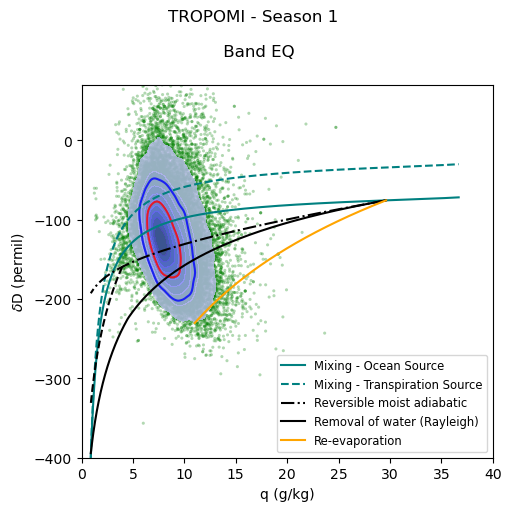

In [4]:

from mpl_toolkits.axes_grid1.inset_locator import inset_axes
ncols=1
nrows=1
h = nrows
w = ncols
fig, axs = plt.subplots(nrows=nrows,ncols=ncols,
                            gridspec_kw = {'wspace':-0.2, 'hspace':-0.5},
                            layout="constrained",
                            figsize=(5,5))
    
df = sat_ds.to_dataframe()

#sns.regplot(data=df, x="h2o_vmr", y="deltaD", scatter=False, ci=95, seed=5000, color='purple',ax=axs)
sns.kdeplot(data=df, x="h2o_vmr", y="deltaD", fill=True,
            alpha=0.8,color='blue',ax=axs,zorder=1)
sns.kdeplot(data=df, x="h2o_vmr", y="deltaD", fill=False,
                alpha=0.8,color='red',ax=axs,zorder=1,levels=[0.5])
sns.kdeplot(data=df, x="h2o_vmr", y="deltaD", fill=False,
                alpha=0.8,color='blue',ax=axs,zorder=1,levels=[0.2])
axs.set_xlim(0,40)
axs.set_ylim(-400,70)
axs.scatter(sat_ds['h2o_vmr'],sat_ds['deltaD'],s=5,alpha=0.3,edgecolors='none',c='green',zorder=0)
NC_ax.noone_curves(tsrc,q0,del0,ax=axs)    # Run and produce plot
axs.legend(loc='best',fontsize='small')
plt.suptitle('TROPOMI - Season 1 \n \n Band '+band+'\n')
#plt.savefig(datap+'TROPOMI_noone_curves_'+bandin+'_S1.png',transparent=True)

plt.show()
plt.clf()
plt.close()